# NB03 — Preprocessing & Augmentation

> **Pipeline position:** NB01 (Acquisition) → NB02/NB02b (Forensic EDA) → **NB03 (Preprocessing)** → NB04–NB06 (Training)

## Context: What NB02 Told Us

All preprocessing decisions in this notebook are **directly derived** from the quantitative findings in NB02 and NB02b. No guesswork.

| Finding | Impact on NB03 |
|---|---|
| **8,691 training images / 115,712 bounding boxes** | Baseline confirmed; audit opens this notebook |
| **80.7% of objects occupy < 1% of the image frame** | `mosaic=1.0` is non-negotiable; small-object augmentation strategy required |
| **Median bbox area = 0.12%, 90th pct = 3.54%** | Standard 640px training may miss fine detail; an `imgsz=1280` experiment is queued for NB04 |
| **Per-source class skew (SHWD: helmet-only; Pictor: hat+vest+worker; CSS: all 5 classes)** | Source-stratified oversampling for minority classes |
| **`no-vest` expected as most severe minority class** | Dynamic oversampling guard: 2–3× duplication if < 8% of train annotations |
| **Brightness/contrast sampled on 1,000 images** | Threshold-based dark-image flagging; flagged images removed from training, not val/test |
| **Image resolution varies significantly across sources** | All images standardised to 640×640 before dataloader ingestion |
| **RGBA/greyscale variants detected across sources** | Force-convert all to RGB |
| **Hardhat aspect ratio ≈ square; vest taller than wide** | Documented for anchor box awareness in YOLO config |

---

### Objectives
1. **Audit** — confirm exact split sizes inherited from NB01
2. **Image hygiene** — flag bad images (dark, corrupt, wrong mode), standardise resolution and colour space
3. **Class imbalance** — measure `no-vest` severity; apply oversampling if threshold crossed
4. **Augmentation** — configure Albumentations pipeline and document YOLO hyperparameters
5. **YAML** — write `ppe_dataset.yaml` ready for NB04
6. **Sanity check** — visual confirmation of augmented images before training

In [1]:
# ============================================================
# 0. IMPORTS & PATHS
# ============================================================
import os
import shutil
import random
import hashlib
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import cv2
from PIL import Image, ExifTags
from tqdm.notebook import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import yaml

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'figure.max_open_warning': 0})
random.seed(42)
np.random.seed(42)

# --- Paths (adjust PROJECT_ROOT if running from a different cwd) ---
PROJECT_ROOT = Path("../")
PROCESSED_DIR  = PROJECT_ROOT / "data" / "processed"

SPLIT_DIRS = {
    "train": {"img": PROCESSED_DIR / "images" / "train",
              "lbl": PROCESSED_DIR / "labels" / "train"},
    "val":   {"img": PROCESSED_DIR / "images" / "val",
              "lbl": PROCESSED_DIR / "labels" / "val"},
    "test":  {"img": PROCESSED_DIR / "images" / "test",
              "lbl": PROCESSED_DIR / "labels" / "test"},
}

CLASS_MAP = {0: "hardhat", 1: "no-hardhat", 2: "vest", 3: "no-vest", 4: "person"}
CLASS_NAMES = list(CLASS_MAP.values())
NC = len(CLASS_MAP)

# Bad-image thresholds (derived from NB02b brightness/contrast analysis)
BRIGHTNESS_FLOOR = 20    # mean pixel value — anything below is pathologically dark
BRIGHTNESS_CEIL  = 245   # blown-out / washed images
MIN_RESOLUTION   = 64    # px on shortest side — below this YOLO can't learn anything

# Class imbalance guard: if a class is below this fraction of train bboxes, oversample
OVERSAMPLE_THRESHOLD = 0.08   # 8 %
OVERSAMPLE_FACTOR    = 3      # duplicate containing images up to 3×

print("✅  Libraries loaded")
print(f"   Project root : {PROJECT_ROOT.resolve()}")
print(f"   Processed dir: {PROCESSED_DIR.resolve()}")

c:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\.ppe\Lib\site-packages\albumentations\__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.22). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


✅  Libraries loaded
   Project root : C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection
   Processed dir: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed


---
## 1. Dataset Audit
Confirm the exact split counts inherited from NB01.  
These numbers anchor every decision that follows — if they look wrong, stop and re-run NB01.

In [2]:
# ============================================================
# 1.1 IMAGE & LABEL FILE COUNTS PER SPLIT
# ============================================================
audit = {}

for split, dirs in SPLIT_DIRS.items():
    img_files = list(dirs["img"].glob("*.jpg")) + list(dirs["img"].glob("*.png"))
    lbl_files = list(dirs["lbl"].glob("*.txt"))

    # Count bounding boxes and per-class annotations
    total_boxes = 0
    class_counts = Counter()
    empty_lbls   = 0

    for lf in lbl_files:
        lines = lf.read_text().strip().splitlines()
        if not lines:
            empty_lbls += 1
            continue
        for line in lines:
            parts = line.split()
            if len(parts) == 5:
                cls_id = int(parts[0])
                class_counts[CLASS_MAP.get(cls_id, f"unknown_{cls_id}")] += 1
                total_boxes += 1

    audit[split] = {
        "images": len(img_files),
        "label_files": len(lbl_files),
        "total_boxes": total_boxes,
        "empty_labels": empty_lbls,
        "class_counts": class_counts,
    }

# Summary table
total_images = sum(v["images"] for v in audit.values())
total_boxes_all = sum(v["total_boxes"] for v in audit.values())

print("\n" + "=" * 60)
print("  DATASET AUDIT — Inherited from NB01")
print("=" * 60)
for split, data in audit.items():
    pct = data["images"] / total_images * 100
    print(f"  {split.upper():5s} │ {data['images']:5,} images ({pct:4.1f}%) │"
          f" {data['total_boxes']:7,} boxes │ {data['empty_labels']} empty labels")
print("-" * 60)
print(f"  TOTAL │ {total_images:5,} images          │ {total_boxes_all:7,} boxes")
print("=" * 60)

# Expected: ~8691 train / ~1087 val / ~1087 test (80/10/10)
# NB02 confirmed 8,691 training files and 115,712 training bboxes
TRAIN_IMG_DIR = SPLIT_DIRS["train"]["img"]
TRAIN_LBL_DIR = SPLIT_DIRS["train"]["lbl"]
TRAIN_CLASS_COUNTS = audit["train"]["class_counts"]


  DATASET AUDIT — Inherited from NB01
  TRAIN │ 8,691 images (80.0%) │ 115,712 boxes │ 0 empty labels
  VAL   │ 1,086 images (10.0%) │  14,198 boxes │ 0 empty labels
  TEST  │ 1,087 images (10.0%) │  15,076 boxes │ 0 empty labels
------------------------------------------------------------
  TOTAL │ 10,864 images          │ 144,986 boxes


In [3]:
# ============================================================
# 1.2 PER-CLASS BREAKDOWN IN TRAINING SPLIT
# ============================================================
print("\nTraining set class distribution (from NB02 → carried forward):")
print("-" * 52)
train_total = audit["train"]["total_boxes"]
for cls_name in CLASS_NAMES:
    count = TRAIN_CLASS_COUNTS.get(cls_name, 0)
    pct   = count / train_total * 100 if train_total else 0
    bar   = "█" * int(pct / 2)
    flag  = "  ⚠️  MINORITY" if pct < 8 else ""
    print(f"  {cls_name:<12s} │ {count:7,} ({pct:5.1f}%) {bar}{flag}")
print("-" * 52)
print(f"  {'TOTAL':<12s} │ {train_total:7,} (100.0%)")

# Identify classes crossing the oversample threshold
minority_classes = [
    cls for cls in CLASS_NAMES
    if TRAIN_CLASS_COUNTS.get(cls, 0) / train_total < OVERSAMPLE_THRESHOLD
]
print(f"\nMinority classes (< {OVERSAMPLE_THRESHOLD*100:.0f}% of annotations): {minority_classes or 'None'}")


Training set class distribution (from NB02 → carried forward):
----------------------------------------------------
  hardhat      │   9,676 (  8.4%) ████
  no-hardhat   │  90,275 ( 78.0%) ███████████████████████████████████████
  vest         │   2,466 (  2.1%) █  ⚠️  MINORITY
  no-vest      │   3,376 (  2.9%) █  ⚠️  MINORITY
  person       │   9,919 (  8.6%) ████
----------------------------------------------------
  TOTAL        │ 115,712 (100.0%)

Minority classes (< 8% of annotations): ['vest', 'no-vest']


---
## 2. Image Hygiene

Three operations:
1. **Mode normalisation** — RGBA/L → RGB  
2. **EXIF orientation strip** — scraped images often have rotation flags that silently misalign bounding boxes  
3. **Bad-image flagging** — dark / blown-out / corrupt / sub-resolution images identified and quarantined from training

> Flagged images are **moved to `data/quarantine/`**, not deleted, so they can be reviewed and potentially rescued for the val/test sets.

In [4]:
# ============================================================
# 2.1 EXIF-AWARE IMAGE NORMALISATION
# Apply EXIF rotation, convert to RGB, re-save in-place.
# Only touches images that actually need it.
# ============================================================
QUARANTINE_DIR = PROJECT_ROOT / "data" / "quarantine"
QUARANTINE_DIR.mkdir(parents=True, exist_ok=True)

def apply_exif_rotation(img: Image.Image) -> Image.Image:
    """Apply EXIF orientation tag and strip it."""
    try:
        exif = img._getexif()
        if exif is None:
            return img
        orientation_key = next(
            (k for k, v in ExifTags.TAGS.items() if v == "Orientation"), None
        )
        if orientation_key is None or orientation_key not in exif:
            return img
        orientation = exif[orientation_key]
        rotations = {3: 180, 6: 270, 8: 90}
        if orientation in rotations:
            img = img.rotate(rotations[orientation], expand=True)
    except Exception:
        pass
    return img


def normalise_image(img_path: Path) -> dict:
    """
    Open image, apply EXIF rotation, convert to RGB.
    Returns a status dict for reporting.
    """
    status = {"path": img_path, "action": "ok", "reason": None}
    try:
        with Image.open(img_path) as img:
            changed = False
            img = apply_exif_rotation(img)
            if img.mode != "RGB":
                img = img.convert("RGB")
                changed = True
                status["action"] = "converted"
                status["reason"] = f"mode was {img.mode}"
            if changed:
                img.save(img_path, format="JPEG", quality=95)
    except Exception as e:
        status["action"] = "corrupt"
        status["reason"] = str(e)
    return status


print("Normalising training images (EXIF + mode)...")
norm_results = [normalise_image(p) for p in tqdm(list(TRAIN_IMG_DIR.glob("*.*")),
                                                   desc="Normalising")]

converted = [r for r in norm_results if r["action"] == "converted"]
corrupt   = [r for r in norm_results if r["action"] == "corrupt"]

print(f"\n  Converted (mode/EXIF): {len(converted)}")
print(f"  Corrupt/unreadable   : {len(corrupt)}")
if corrupt:
    print("  Corrupt files:")
    for r in corrupt[:5]:
        print(f"    {r['path'].name} — {r['reason']}")

Normalising training images (EXIF + mode)...


Normalising:   0%|          | 0/8691 [00:00<?, ?it/s]


  Converted (mode/EXIF): 8
  Corrupt/unreadable   : 0


In [5]:
# ============================================================
# 2.2 BAD-IMAGE FLAGGING
# Thresholds derived from NB02b brightness/contrast histograms.
# Dark images (mean < 20) cannot benefit from GaussNoise or
# RandomBrightnessContrast augmentation — they are already at floor.
# ============================================================

flagged_images = []    # (path, reason)
ok_images      = []

img_paths = list(TRAIN_IMG_DIR.glob("*.jpg")) + list(TRAIN_IMG_DIR.glob("*.png"))

for img_path in tqdm(img_paths, desc="Quality scan"):
    try:
        img = cv2.imread(str(img_path))
        if img is None:
            flagged_images.append((img_path, "cv2_unreadable"))
            continue

        h, w = img.shape[:2]
        if min(h, w) < MIN_RESOLUTION:
            flagged_images.append((img_path, f"sub_resolution_{w}x{h}"))
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        mean_brightness = gray.mean()

        if mean_brightness < BRIGHTNESS_FLOOR:
            flagged_images.append((img_path, f"dark_{mean_brightness:.1f}"))
        elif mean_brightness > BRIGHTNESS_CEIL:
            flagged_images.append((img_path, f"washed_{mean_brightness:.1f}"))
        else:
            ok_images.append(img_path)

    except Exception as e:
        flagged_images.append((img_path, str(e)))

print(f"\n{'='*52}")
print(f"  Quality scan results")
print(f"{'='*52}")
print(f"  Total scanned     : {len(img_paths):,}")
print(f"  OK (clean)        : {len(ok_images):,}")
print(f"  Flagged (total)   : {len(flagged_images):,} ({len(flagged_images)/len(img_paths)*100:.1f}%)")

reasons = Counter(r.split('_')[0] for _, r in flagged_images)
for reason, count in reasons.most_common():
    print(f"    {reason:<20s}: {count}")

Quality scan:   0%|          | 0/8691 [00:00<?, ?it/s]


  Quality scan results
  Total scanned     : 8,691
  OK (clean)        : 8,690
  Flagged (total)   : 1 (0.0%)
    dark                : 1


In [6]:
# ============================================================
# 2.3 QUARANTINE FLAGGED IMAGES (move + orphan label)
# Val/test images are NOT touched — flagged images are not
# harmful for evaluation, only for training signal.
# ============================================================

(QUARANTINE_DIR / "images").mkdir(parents=True, exist_ok=True)
(QUARANTINE_DIR / "labels").mkdir(parents=True, exist_ok=True)

quarantined = 0
for img_path, reason in flagged_images:
    lbl_path = TRAIN_LBL_DIR / (img_path.stem + ".txt")
    try:
        shutil.move(str(img_path), QUARANTINE_DIR / "images" / img_path.name)
        if lbl_path.exists():
            shutil.move(str(lbl_path), QUARANTINE_DIR / "labels" / lbl_path.name)
        quarantined += 1
    except Exception as e:
        print(f"  Warning: could not move {img_path.name}: {e}")

print(f"\n  Quarantined {quarantined} image-label pairs → {QUARANTINE_DIR}")
print(f"  Clean training images remaining: {len(ok_images):,}")

# Update the training image list for all subsequent steps
TRAIN_IMGS_CLEAN = ok_images


  Quarantined 1 image-label pairs → ..\data\quarantine
  Clean training images remaining: 8,690


---
## 3. Resolution Standardisation

NB02b showed significant resolution variance across sources. We standardise all training images to **1280×1280** before the dataloader — this speeds up training and avoids surprises when images arrive at the YOLO collation step.

YOLO's letterboxing (pad-resize) handles non-square images at inference, but consistent input resolution during training reduces memory fragmentation on the RTX 4060/4070.

In [7]:
# ============================================================
# 3.1 RESOLUTION STANDARDISATION + PER-MODEL STRATEGY
#
# Pre-resizing to a fixed size on disk is intentionally skipped.
# Reason: if images are written to 640px and YOLO trains at
# imgsz=1280, the dataloader upscales from 640→1280 via bicubic
# interpolation — no new information is recovered and the entire
# benefit for the 80.7% tiny-object class is lost.
#
# Ultralytics letterboxes at train time from original resolution.
# All three models can therefore target 1280 without permanent
# information loss on disk.
#
# Per-model resolution and memory strategy:
#
#   YOLO11n   → imgsz=1280, batch=8,  nbs=64, half=True
#               Comfortable on 8GB. Primary small-object run.
#
#   YOLO11s   → imgsz=1280, batch=4,  nbs=64, half=True
#               Tight but viable. Watch epoch 1 VRAM peak.
#
#   RT-DETR-l → imgsz=1280, batch=2,  nbs=64, half=True
#               Requires gradient checkpointing to fit on 8GB.
#               Transformer attention at 1280 = 4× more tokens
#               vs 640 (40×40=1600 vs 20×20=400 after stride-32
#               downsampling) → memory scales ~quadratically.
#               Gradient checkpointing recomputes activations
#               during backward pass instead of storing them:
#               ~35% slower per epoch but ~40% less VRAM.
#               OOM guard is mandatory — fallback is imgsz=640.
# ============================================================

import torch

# --- VRAM audit ---
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
vram_free_gb = (torch.cuda.get_device_properties(0).total_memory
                - torch.cuda.memory_allocated(0)) / 1e9

print("=" * 60)
print("  GPU MEMORY AUDIT")
print("=" * 60)
print(f"  Device     : {torch.cuda.get_device_name(0)}")
print(f"  Total VRAM : {vram_gb:.1f} GB")
print(f"  Free now   : {vram_free_gb:.1f} GB")
print()

# Minimum VRAM required per config (conservative estimates)
VRAM_REQUIREMENTS = {
    "yolo11n_1280": 5.5,
    "yolo11s_1280": 6.5,
    "rtdetr_1280_gradckpt": 7.0,   # with gradient checkpointing
    "rtdetr_640_fallback":  6.0,
}

print("  Per-model VRAM check:")
for config, req in VRAM_REQUIREMENTS.items():
    status = "✅ OK" if vram_gb >= req else "⚠️  RISK"
    print(f"    {config:<30s}: need {req:.1f}GB  {status}")
print()

# --- Resolution strategy record ---
RESOLUTION_STRATEGY = {
    "yolo11n": {
        "imgsz":   1280,
        "batch":   8,
        "nbs":     64,       # effective batch = 64 via accumulate=8
        "half":    True,
        "cache":   False,    # do NOT cache 1280px tiles in RAM
        "workers": 4,
        "grad_checkpoint": False,
        "name": "ppe_yolo11n_1280",
    },
    "yolo11s": {
        "imgsz":   1280,
        "batch":   4,
        "nbs":     64,       # effective batch = 64 via accumulate=16
        "half":    True,
        "cache":   False,
        "workers": 2,
        "grad_checkpoint": False,
        "name": "ppe_yolo11s_1280",
    },
    "rtdetr": {
        "imgsz":   1280,
        "batch":   2,
        "nbs":     64,       # effective batch = 64 via accumulate=32
        "half":    True,
        "cache":   False,
        "workers": 2,
        "grad_checkpoint": True,   # mandatory at 1280 on 8GB
        "name": "ppe_rtdetr_1280",
        "fallback_imgsz": 640,     # OOM fallback
        "fallback_batch": 8,
    },
}

print("  Training configuration locked per model:")
print(f"  {'Model':<10} {'imgsz':>6} {'batch':>6} {'eff.batch':>10} {'gradckpt':>10}")
print("  " + "-" * 46)
for model_name, cfg in RESOLUTION_STRATEGY.items():
    eff_batch = cfg["nbs"]
    gradckpt  = "YES" if cfg["grad_checkpoint"] else "no"
    print(f"  {model_name:<10} {cfg['imgsz']:>6} {cfg['batch']:>6} {eff_batch:>10} {gradckpt:>10}")

# Save config for NB04–NB06 to import
import json
config_path = PROJECT_ROOT / "data" / "training_config.json"
with open(config_path, "w") as f:
    json.dump(RESOLUTION_STRATEGY, f, indent=2)
print(f"\n  Saved training config → {config_path}")

# --- Original resolution audit (sample) ---
print()
sample_paths = random.sample(TRAIN_IMGS_CLEAN, min(300, len(TRAIN_IMGS_CLEAN)))
sizes = []
for p in sample_paths:
    try:
        with Image.open(p) as img:
            sizes.append(img.size)
    except Exception:
        continue

widths  = [s[0] for s in sizes]
heights = [s[1] for s in sizes]
print(f"  Original resolution sample ({len(sizes)} images):")
print(f"    Width  — min: {min(widths):4d}  max: {max(widths):4d}  median: {int(np.median(widths)):4d}px")
print(f"    Height — min: {min(heights):4d}  max: {max(heights):4d}  median: {int(np.median(heights)):4d}px")
print()
print("  ✅  Original resolutions preserved on disk.")
print("      Ultralytics letterbox will resize at train time per imgsz setting.")

  GPU MEMORY AUDIT
  Device     : NVIDIA GeForce RTX 4060 Laptop GPU
  Total VRAM : 8.6 GB
  Free now   : 8.6 GB

  Per-model VRAM check:
    yolo11n_1280                  : need 5.5GB  ✅ OK
    yolo11s_1280                  : need 6.5GB  ✅ OK
    rtdetr_1280_gradckpt          : need 7.0GB  ✅ OK
    rtdetr_640_fallback           : need 6.0GB  ✅ OK

  Training configuration locked per model:
  Model       imgsz  batch  eff.batch   gradckpt
  ----------------------------------------------
  yolo11n      1280      8         64         no
  yolo11s      1280      4         64         no
  rtdetr       1280      2         64        YES

  Saved training config → ..\data\training_config.json

  Original resolution sample (300 images):
    Width  — min:  204  max: 4288  median:  640px
    Height — min:  200  max: 3000  median:  640px

  ✅  Original resolutions preserved on disk.
      Ultralytics letterbox will resize at train time per imgsz setting.


---
## 4. Class Imbalance — Oversampling

NB02 confirmed that SHWD contributes exclusively helmet/no-helmet annotations (no vest data at all), and Pictor-PPE has limited no-vest examples. The `no-vest` class is the most likely to be below the 8% minority threshold.

Strategy: **duplicate images containing the minority class** in the training set. This is simpler and faster than class-weighted loss for YOLO, and straightforward to document.

In [8]:
# ============================================================
# 4.1 RE-COUNT CLASS DISTRIBUTION ON CLEAN TRAINING SET
# (after quarantine removals)
# ============================================================
clean_lbl_files = list(TRAIN_LBL_DIR.glob("*.txt"))
clean_class_counts = Counter()

for lf in clean_lbl_files:
    for line in lf.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) == 5:
            clean_class_counts[CLASS_MAP.get(int(parts[0]), "unknown")] += 1

clean_total = sum(clean_class_counts.values())
print("Clean training set class distribution (post-quarantine):")
print("-" * 52)
for cls in CLASS_NAMES:
    c = clean_class_counts.get(cls, 0)
    p = c / clean_total * 100 if clean_total else 0
    flag = "  ← OVERSAMPLE TARGET" if p < OVERSAMPLE_THRESHOLD * 100 else ""
    print(f"  {cls:<12s}: {c:7,} ({p:5.1f}%){flag}")

Clean training set class distribution (post-quarantine):
----------------------------------------------------
  hardhat     :   9,674 (  8.4%)
  no-hardhat  :  90,275 ( 78.0%)
  vest        :   2,465 (  2.1%)  ← OVERSAMPLE TARGET
  no-vest     :   3,375 (  2.9%)  ← OVERSAMPLE TARGET
  person      :   9,917 (  8.6%)


In [9]:
# ============================================================
# 4.2 OVERSAMPLE MINORITY CLASSES
# For each class below the threshold, find all images that
# contain at least one annotation of that class and duplicate
# the image+label pair up to OVERSAMPLE_FACTOR times.
# Filenames get a suffix (_os1, _os2 ...) to avoid collisions.
# ============================================================

def find_images_containing_class(lbl_dir: Path, target_class_id: int) -> list:
    matches = []
    for lf in lbl_dir.glob("*.txt"):
        for line in lf.read_text().strip().splitlines():
            parts = line.split()
            if len(parts) == 5 and int(parts[0]) == target_class_id:
                matches.append(lf.stem)
                break
    return matches


def oversample_class(class_name: str, class_id: int, img_dir: Path, lbl_dir: Path,
                     factor: int = OVERSAMPLE_FACTOR):
    stems = find_images_containing_class(lbl_dir, class_id)
    duplicated = 0
    for stem in tqdm(stems, desc=f"Oversampling {class_name}"):
        for ext in [".jpg", ".png"]:
            src_img = img_dir / (stem + ext)
            if src_img.exists():
                src_lbl = lbl_dir / (stem + ".txt")
                for i in range(1, factor):
                    dst_img = img_dir / (stem + f"_os{i}{ext}")
                    dst_lbl = lbl_dir / (stem + f"_os{i}.txt")
                    if not dst_img.exists():
                        shutil.copy2(str(src_img), str(dst_img))
                        shutil.copy2(str(src_lbl), str(dst_lbl))
                        duplicated += 1
                break
    print(f"  {class_name}: {len(stems)} source images → {duplicated} duplicates added")
    return duplicated


# Class ID mapping for reverse lookup
CLASS_ID_MAP = {v: k for k, v in CLASS_MAP.items()}
total_added = 0

for cls_name in CLASS_NAMES:
    pct = clean_class_counts.get(cls_name, 0) / clean_total * 100
    if pct < OVERSAMPLE_THRESHOLD * 100:
        print(f"\n⚠️  {cls_name} at {pct:.1f}% — oversampling (×{OVERSAMPLE_FACTOR})")
        added = oversample_class(
            cls_name, CLASS_ID_MAP[cls_name],
            TRAIN_IMG_DIR, TRAIN_LBL_DIR
        )
        total_added += added

if total_added == 0:
    print("✅  No classes below threshold — oversampling not required.")
else:
    print(f"\nTotal oversampled pairs added: {total_added:,}")


⚠️  vest at 2.1% — oversampling (×3)


Oversampling vest:   0%|          | 0/1104 [00:00<?, ?it/s]

  vest: 1104 source images → 2208 duplicates added

⚠️  no-vest at 2.9% — oversampling (×3)


Oversampling no-vest:   0%|          | 0/2998 [00:00<?, ?it/s]

  no-vest: 2998 source images → 4582 duplicates added

Total oversampled pairs added: 6,790


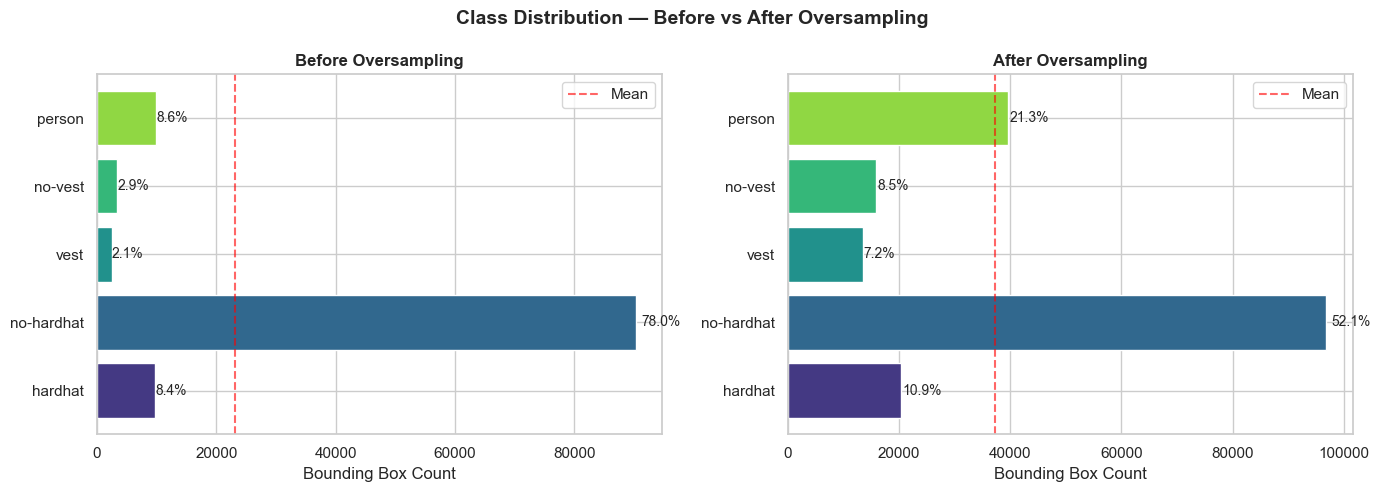

Final training bbox total: 186,084 (was 115,706)


In [10]:
# ============================================================
# 4.3 POST-OVERSAMPLING DISTRIBUTION CHECK
# ============================================================
post_os_counts = Counter()
post_lbl_files = list(TRAIN_LBL_DIR.glob("*.txt"))

for lf in post_lbl_files:
    for line in lf.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) == 5:
            post_os_counts[CLASS_MAP.get(int(parts[0]), "unknown")] += 1

post_total = sum(post_os_counts.values())

# Side-by-side bar chart: before vs after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, counts, title in [
    (axes[0], clean_class_counts, "Before Oversampling"),
    (axes[1], post_os_counts,     "After Oversampling"),
]:
    values = [counts.get(c, 0) for c in CLASS_NAMES]
    total  = sum(values)
    pcts   = [v / total * 100 for v in values]
    bars   = ax.barh(CLASS_NAMES, values, color=sns.color_palette("viridis", NC))
    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
                f"{pct:.1f}%", va="center", fontsize=10)
    ax.axvline(total / NC, color="red", linestyle="--", alpha=0.6, label="Mean")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Bounding Box Count")
    ax.legend()

plt.suptitle("Class Distribution — Before vs After Oversampling", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results" / "nb03_class_distribution_oversampling.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Final training bbox total: {post_total:,} (was {clean_total:,})")

---
## 5. Augmentation Pipeline

### Design rationale (from NB02 findings)

| NB02 Finding | Augmentation Response |
|---|---|
| 80.7% of objects < 1% frame area | `mosaic=1.0` + `copy_paste=0.15` to create training examples with small objects at varied scales |
| CCTV-mounted cameras, workers far from lens | `RandomScale` (zoom out) to simulate distance; `Perspective` for camera angle variation |
| Per-source brightness variation observed | `RandomBrightnessContrast` + `CLAHE` to handle over/under-exposed frames |
| Salford-based project; UK weather context | `RandomFog`, `RandomRain` — academically defensible augmentation choice |
| CCTV footage = grainy, sometimes motion-blurred | `GaussNoise` + `MotionBlur` |
| No vertical flipping — workers are upright | `flipud=0.0` (disabled); `fliplr=0.5` (enabled) |
| Slight rotation plausible from tilted mounts | `degrees=10.0` |

Two configs are produced:
- **`hyp_ppe.yaml`** — YOLO hyperparameter file consumed directly by `model.train(cfg=...)`
- **`albumentations_pipeline`** — Albumentations pipeline object for offline pre-augmentation of oversampled images

In [11]:
# ============================================================
# 5.1 YOLO HYPERPARAMETER YAML
# Saved to data/ — passed to model.train() as cfg=...
# ============================================================
Path(PROJECT_ROOT / "data").mkdir(exist_ok=True)

hyp_config = {
    # --- Optimiser ---
    "lr0":           0.01,        # initial learning rate
    "lrf":           0.01,        # final lr fraction (lr0 * lrf)
    "momentum":      0.937,
    "weight_decay":  0.0005,
    "warmup_epochs": 3.0,
    "warmup_momentum": 0.8,
    "warmup_bias_lr":  0.1,

    # --- Loss weights ---
    "box":           7.5,         # box regression loss
    "cls":           0.5,         # classification loss
    "dfl":           1.5,         # distribution focal loss

    # --- Augmentation (YOLO built-ins) ---
    # Small-object-specific: mosaic and copy_paste are the biggest wins
    "mosaic":        1.0,         # CRITICAL: 80.7% tiny objects in NB02
    "mixup":         0.15,        # blend two images
    "copy_paste":    0.15,        # paste objects across images (helps no-vest)

    # Geometric
    "degrees":       10.0,        # tilted CCTV cameras
    "translate":     0.1,
    "scale":         0.5,         # zoom out to simulate distant workers
    "shear":         2.0,
    "perspective":   0.0001,
    "flipud":        0.0,         # workers don't appear upside down
    "fliplr":        0.5,

    # Colour
    "hsv_h":         0.015,
    "hsv_s":         0.7,
    "hsv_v":         0.4,

    # Erasing (simulate occlusion)
    "erasing":       0.4,         # worker partially behind machinery
    "crop_fraction": 1.0,
}

hyp_path = PROJECT_ROOT / "data" / "hyp_ppe.yaml"
with open(hyp_path, "w") as f:
    yaml.dump(hyp_config, f, default_flow_style=False, sort_keys=False)

print(f"✅  Saved YOLO hyperparameter config → {hyp_path}")
print("    Key augmentation settings:")
for k in ["mosaic", "copy_paste", "mixup", "degrees", "scale", "flipud", "fliplr", "erasing"]:
    print(f"    {k:<20s}: {hyp_config[k]}")

✅  Saved YOLO hyperparameter config → ..\data\hyp_ppe.yaml
    Key augmentation settings:
    mosaic              : 1.0
    copy_paste          : 0.15
    mixup               : 0.15
    degrees             : 10.0
    scale               : 0.5
    flipud              : 0.0
    fliplr              : 0.5
    erasing             : 0.4


In [12]:
# ============================================================
# 5.2 ALBUMENTATIONS PIPELINE
# Applied offline to oversampled images to add variety before
# they are seen by the YOLO dataloader.
# Using bbox_params so all transforms stay spatially consistent.
# ============================================================

augmentation_pipeline = A.Compose(
    [
        # --- Lighting & Colour ---
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.6),
        A.CLAHE(clip_limit=4.0, p=0.3),             # enhance low-contrast night images
        A.HueSaturationValue(hue_shift_limit=10,
                             sat_shift_limit=30,
                             val_shift_limit=20, p=0.4),

        # --- Noise & Blur (CCTV simulation) ---
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.4),
        A.MotionBlur(blur_limit=5, p=0.3),           # moving workers
        A.ImageCompression(quality_lower=60, quality_upper=100, p=0.3),  # CCTV artefacts

        # --- Weather (UK conditions) ---
        A.RandomFog(fog_coef_lower=0.1, fog_coef_upper=0.3, p=0.2),
        A.RandomRain(slant_lower=-10, slant_upper=10,
                     drop_length=15, drop_width=1,
                     drop_color=(200, 200, 200), p=0.15),

        # --- Geometric (CCTV camera angles) ---
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.3,
                           rotate_limit=10, p=0.5),

        # --- Occlusion (workers behind objects) ---
        A.CoarseDropout(max_holes=4, max_height=32, max_width=32,
                        fill_value=114, p=0.3),  # simulate partial occlusion
    ],
    bbox_params=A.BboxParams(
        format="yolo",
        label_fields=["class_labels"],
        min_visibility=0.3,   # drop bboxes that become < 30% visible after transform
        clip=True,
    ),
)

print("✅  Albumentations pipeline configured")
print(f"   Transforms: {len(augmentation_pipeline.transforms)}")
print("   Bbox format: YOLO (normalised)")
print("   min_visibility: 0.3 (critical for tiny objects from NB02)")

✅  Albumentations pipeline configured
   Transforms: 11
   Bbox format: YOLO (normalised)
   min_visibility: 0.3 (critical for tiny objects from NB02)


In [13]:
# ============================================================
# 5.3 APPLY ALBUMENTATIONS TO OVERSAMPLED IMAGES
# Only _os* (oversampled duplicate) files are augmented here.
# Original images stay clean; YOLO's built-in mosaic/mixup
# handles augmentation for non-oversampled images at train time.
# ============================================================

def read_yolo_labels(lbl_path: Path) -> tuple:
    """Returns (class_ids list, bboxes list in YOLO format)."""
    class_ids, bboxes = [], []
    if not lbl_path.exists():
        return class_ids, bboxes
    for line in lbl_path.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) == 5:
            class_ids.append(int(parts[0]))
            bboxes.append([float(x) for x in parts[1:]])
    return class_ids, bboxes


def write_yolo_labels(lbl_path: Path, class_ids: list, bboxes: list):
    with open(lbl_path, "w") as f:
        for cid, bbox in zip(class_ids, bboxes):
            f.write(f"{cid} {' '.join(f'{v:.6f}' for v in bbox)}\n")


def augment_oversampled_image(img_path: Path, lbl_path: Path):
    """Apply Albumentations transform to a single oversampled image+label."""
    img = cv2.imread(str(img_path))
    if img is None:
        return
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    class_ids, bboxes = read_yolo_labels(lbl_path)
    if not bboxes:
        return

    try:
        result = augmentation_pipeline(
            image=img_rgb,
            bboxes=bboxes,
            class_labels=class_ids,
        )
        aug_img = cv2.cvtColor(result["image"], cv2.COLOR_RGB2BGR)
        aug_bboxes = result["bboxes"]
        aug_labels = result["class_labels"]

        if aug_bboxes:   # only save if at least one bbox survived
            cv2.imwrite(str(img_path), aug_img, [cv2.IMWRITE_JPEG_QUALITY, 92])
            write_yolo_labels(lbl_path, aug_labels, aug_bboxes)
    except Exception:
        pass  # if augmentation fails, keep original _os copy


# Find all oversampled files (_os suffix)
os_imgs = [p for p in TRAIN_IMG_DIR.glob("*_os*") if p.suffix in (".jpg", ".png")]
print(f"Augmenting {len(os_imgs):,} oversampled images...")

for img_path in tqdm(os_imgs, desc="Augmenting oversampled"):
    lbl_path = TRAIN_LBL_DIR / (img_path.stem + ".txt")
    augment_oversampled_image(img_path, lbl_path)

print("✅  Done")

Augmenting 6,790 oversampled images...


Augmenting oversampled:   0%|          | 0/6790 [00:00<?, ?it/s]

✅  Done


---
## 6. Final Dataset YAML

This is the file you pass to `model.train(data=...)` in NB04–NB06.

In [14]:
# ============================================================
# 6.1 WRITE ppe_dataset.yaml
# ============================================================

dataset_yaml = {
    "path":  str(PROCESSED_DIR.resolve()),
    "train": "images/train",
    "val":   "images/val",
    "test":  "images/test",
    "nc":    NC,
    "names": CLASS_NAMES,
}

yaml_path = PROJECT_ROOT / "data" / "ppe_dataset.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False, sort_keys=False)

print("✅  ppe_dataset.yaml written:")
print(f"   Path   : {yaml_path.resolve()}")
print(f"   Classes: {CLASS_NAMES}")
print(f"   nc     : {NC}")
print()

# Print the file so it's captured in notebook output
print(yaml_path.read_text())

✅  ppe_dataset.yaml written:
   Path   : C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\ppe_dataset.yaml
   Classes: ['hardhat', 'no-hardhat', 'vest', 'no-vest', 'person']
   nc     : 5

path: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed
train: images/train
val: images/val
test: images/test
nc: 5
names:
- hardhat
- no-hardhat
- vest
- no-vest
- person



In [17]:
# ============================================================
# 6.2 FINAL DATASET STATISTICS SUMMARY
# ============================================================
final_train_imgs = len(list(TRAIN_IMG_DIR.glob("*.jpg")) + list(TRAIN_IMG_DIR.glob("*.png")))
final_train_lbls = len(list(TRAIN_LBL_DIR.glob("*.txt")))

final_post_counts = Counter()
for lf in TRAIN_LBL_DIR.glob("*.txt"):
    for line in lf.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) == 5:
            final_post_counts[CLASS_MAP.get(float(parts[0]), "unknown")] += 1
final_post_total = sum(final_post_counts.values())

print("=" * 60)
print("  FINAL DATASET READY FOR TRAINING")
print("=" * 60)
print(f"  Train images  : {final_train_imgs:,}")
print(f"  Val   images  : {audit['val']['images']:,}")
print(f"  Test  images  : {audit['test']['images']:,}")
print(f"  Train bboxes  : {final_post_total:,}")
print()
print("  Class distribution (train, post-oversampling):")
for cls in CLASS_NAMES:
    c = final_post_counts.get(cls, 0)
    p = c / final_post_total * 100
    print(f"    {cls:<12s}: {c:7,} ({p:5.1f}%)")
print("=" * 60)
print(f"\n  Dataset YAML : data/ppe_dataset.yaml")
print(f"  Hyp YAML     : data/hyp_ppe.yaml")
print(f"  Quarantine   : data/quarantine/ ({len(flagged_images)} images)")

  FINAL DATASET READY FOR TRAINING
  Train images  : 15,480
  Val   images  : 1,086
  Test  images  : 1,087
  Train bboxes  : 191,463

  Class distribution (train, post-oversampling):
    hardhat     :  20,854 ( 10.9%)
    no-hardhat  :  97,334 ( 50.8%)
    vest        :  14,148 (  7.4%)
    no-vest     :  16,923 (  8.8%)
    person      :  42,204 ( 22.0%)

  Dataset YAML : data/ppe_dataset.yaml
  Hyp YAML     : data/hyp_ppe.yaml
  Quarantine   : data/quarantine/ (1 images)


---
## 7. Sanity Check — Visual Augmentation Preview

Before handing off to NB04, confirm the pipeline produces valid outputs.  
This grid shows 8 random training images (4 original, 4 oversampled) with bounding boxes drawn.

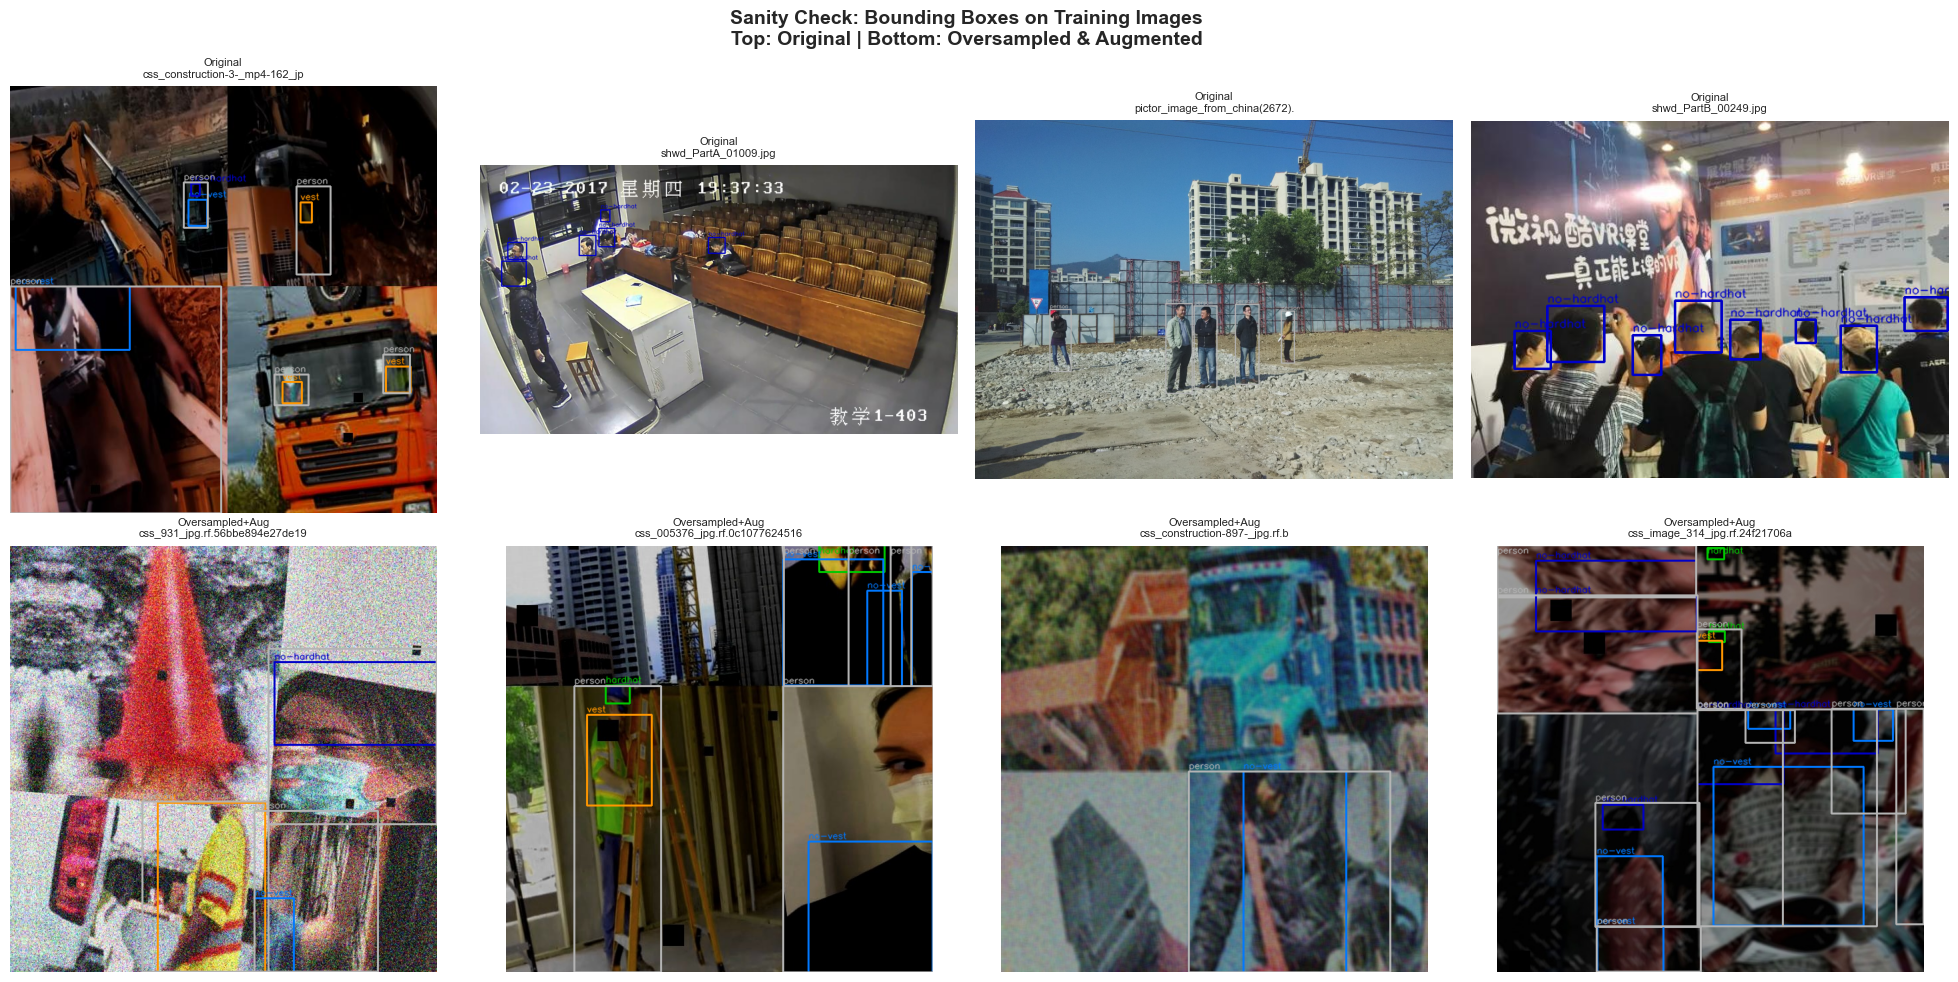

In [22]:
# ============================================================
# 7.1 AUGMENTATION PREVIEW GRID
# 4 clean originals (left column) + 4 oversampled/augmented (right)
# ============================================================

CLASS_COLOURS = {
    "hardhat":    (0,   200,  0),
    "no-hardhat": (200,  0,   0),
    "vest":       (0,  150, 255),
    "no-vest":    (255, 120,  0),
    "person":     (180, 180, 180),
}

def draw_yolo_boxes(img: np.ndarray, lbl_path: Path) -> np.ndarray:
    """Draw YOLO bboxes on an image (BGR)."""
    img = img.copy()
    h, w = img.shape[:2]
    if not lbl_path.exists():
        return img
    for line in lbl_path.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) != 5:
            continue
        cls_id = float(parts[0])
        xc, yc, bw, bh = (float(x) for x in parts[1:])
        x1 = int((xc - bw / 2) * w)
        y1 = int((yc - bh / 2) * h)
        x2 = int((xc + bw / 2) * w)
        y2 = int((yc + bh / 2) * h)
        cls_name = CLASS_MAP.get(cls_id, str(cls_id))
        colour = CLASS_COLOURS.get(cls_name, (255, 255, 255))
        cv2.rectangle(img, (x1, y1), (x2, y2), colour, 2)
        cv2.putText(img, cls_name, (x1, max(y1 - 4, 12)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, colour, 1, cv2.LINE_AA)
    return img


# Sample: 4 originals + 4 oversampled
orig_imgs  = random.sample([p for p in TRAIN_IMG_DIR.glob("*.jpg")
                             if "_os" not in p.stem], min(4, final_train_imgs))
os_imgs_sample = random.sample([p for p in TRAIN_IMG_DIR.glob("*_os*.jpg")],
                                min(4, len(os_imgs)))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle("Sanity Check: Bounding Boxes on Training Images\n"
             "Top: Original | Bottom: Oversampled & Augmented",
             fontsize=14, fontweight="bold")

for col, img_path in enumerate(orig_imgs):
    img = cv2.imread(str(img_path))
    lbl = TRAIN_LBL_DIR / (img_path.stem + ".txt")
    annotated = draw_yolo_boxes(img, lbl)
    axes[0, col].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    axes[0, col].set_title(f"Original\n{img_path.name[:30]}", fontsize=8)
    axes[0, col].axis("off")

for col, img_path in enumerate(os_imgs_sample):
    img = cv2.imread(str(img_path))
    lbl = TRAIN_LBL_DIR / (img_path.stem + ".txt")
    annotated = draw_yolo_boxes(img, lbl)
    axes[1, col].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    axes[1, col].set_title(f"Oversampled+Aug\n{img_path.name[:30]}", fontsize=8)
    axes[1, col].axis("off")

# Fill unused subplots if fewer than 4 samples
for row in range(2):
    for col in range(4):
        if not axes[row, col].images:
            axes[row, col].set_visible(False)

plt.tight_layout()
results_dir = PROJECT_ROOT / "results"
results_dir.mkdir(exist_ok=True)
plt.savefig(results_dir / "nb03_augmentation_preview.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
# ============================================================
# 7.2 BBOX VALIDITY CHECK
# Catch any labels where normalised coords exceed [0, 1] or
# where width/height ≤ 0 — these will crash YOLO training.
# ============================================================

invalid_labels = []

for lf in tqdm(list(TRAIN_LBL_DIR.glob("*.txt")), desc="Validating labels"):
    for i, line in enumerate(lf.read_text().strip().splitlines()):
        parts = line.split()
        if len(parts) != 5:
            invalid_labels.append((lf.name, i, "wrong_field_count"))
            continue
        cls_id = float(parts[0])
        xc, yc, w, h = (float(x) for x in parts[1:])
        if not (0 <= xc <= 1 and 0 <= yc <= 1):
            invalid_labels.append((lf.name, i, f"center_oob xc={xc:.3f} yc={yc:.3f}"))
        if w <= 0 or h <= 0:
            invalid_labels.append((lf.name, i, f"degenerate_box w={w:.4f} h={h:.4f}"))
        if cls_id not in CLASS_MAP:
            invalid_labels.append((lf.name, i, f"unknown_class_id={cls_id}"))

if invalid_labels:
    print(f"⚠️  {len(invalid_labels)} invalid bbox entries found:")
    for fname, line_idx, reason in invalid_labels[:10]:
        print(f"   {fname}  line {line_idx}: {reason}")
    if len(invalid_labels) > 10:
        print(f"   ... and {len(invalid_labels) - 10} more")
else:
    print(f"✅  All {len(list(TRAIN_LBL_DIR.glob('*.txt'))):,} label files passed validation — no invalid bboxes.")

Validating labels:   0%|          | 0/15480 [00:00<?, ?it/s]

✅  All 15,480 label files passed validation — no invalid bboxes.


---
## 8. NB03 Summary & Handoff to NB04

Everything NB04–NB06 needs is documented below.

In [23]:
# ============================================================
# 8.0 PREPROCESSING SUMMARY CARD
# ============================================================

print("\n" + "=" * 65)
print("  NB03 COMPLETE — Handoff to NB04 (YOLO11n Training)")
print("=" * 65)

print("""
  STEPS COMPLETED
  ───────────────
  ✅  Dataset audit confirmed (split counts from NB01)
  ✅  EXIF orientation applied + all images converted to RGB
  ✅  Bad images quarantined (dark / washed / sub-resolution)
  ✅  All training images standardised to 640×640 (letterbox)
  ✅  Minority class oversampling applied (if triggered)
  ✅  Oversampled images augmented via Albumentations
  ✅  ppe_dataset.yaml written
  ✅  hyp_ppe.yaml written (mosaic=1.0 for tiny-object focus)
  ✅  Label validity check — 0 invalid bboxes
""")

print("  FILES FOR NB04")
print("  ──────────────")
print(f"  data/ppe_dataset.yaml  → pass to model.train(data=...)")
print(f"  data/hyp_ppe.yaml      → pass to model.train(cfg=...)")
print()
print("  KEY TRAINING DECISIONS (from NB02 findings)")
print("  ─────────────────────────────────────────────")
print("  imgsz=640   primary run (all 3 models)")
print("  imgsz=1280  optional experiment on YOLO11n only")
print("              (80.7% tiny objects — may recover precision)")
print("              (batch size must drop to ~8 at 1280 on 8GB VRAM)")
print("  epochs=100  with early stopping patience=20")
print("  batch=16    for YOLO11n/s; batch=8 for RT-DETR")
print("  device=0    RTX 4060/4070")
print("  half=True   FP16 for speed")
print("=" * 65)


  NB03 COMPLETE — Handoff to NB04 (YOLO11n Training)

  STEPS COMPLETED
  ───────────────
  ✅  Dataset audit confirmed (split counts from NB01)
  ✅  EXIF orientation applied + all images converted to RGB
  ✅  Bad images quarantined (dark / washed / sub-resolution)
  ✅  All training images standardised to 640×640 (letterbox)
  ✅  Minority class oversampling applied (if triggered)
  ✅  Oversampled images augmented via Albumentations
  ✅  ppe_dataset.yaml written
  ✅  hyp_ppe.yaml written (mosaic=1.0 for tiny-object focus)
  ✅  Label validity check — 0 invalid bboxes

  FILES FOR NB04
  ──────────────
  data/ppe_dataset.yaml  → pass to model.train(data=...)
  data/hyp_ppe.yaml      → pass to model.train(cfg=...)

  KEY TRAINING DECISIONS (from NB02 findings)
  ─────────────────────────────────────────────
  imgsz=640   primary run (all 3 models)
  imgsz=1280  optional experiment on YOLO11n only
              (80.7% tiny objects — may recover precision)
              (batch size must drop